# Data Visualization (CS503) - HW1

**Bishop's University - Department of Computer Science**

This notebook contains my solution for HW1:

- **Part I** - reproduce the dumbbell chart from the `Dumbbell 1` tab of `Dumbbell.xlsx`
  (traffic fatality rate per 100 million vehicle miles travelled, by US state, 2007 vs 2017).
- **Part II** - reproduce the Chongqing daily-case histograms for several bin sizes, build a
  province-vs-province similarity matrix using the Bhattacharyya coefficient, and visualise it
  as a heatmap for each bin size.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

## Part I - Dumbbell Chart

The data lives in the `Dumbbell 1` tab. Column B is the state name, column C the 2007 rate and
column D the 2017 rate. The first couple of rows are the title/header, so I skip down to the
header row and keep only the three columns I need.

In [2]:
xlsx_path = "Dumbbell.xlsx"

raw = pd.read_excel(xlsx_path, sheet_name="Dumbbell 1", header=1, usecols="B:D")
raw.columns = ["State", "2007", "2017"]

# keep real rows only (drop the blank anchor rows and the "Source:" footer)
dumbbell = raw.dropna(subset=["State", "2007", "2017"]).copy()
dumbbell = dumbbell[~dumbbell["State"].astype(str).str.startswith("Source")]

# order states by their 2017 rate (lowest first) so the chart reads top-to-bottom
dumbbell = dumbbell.sort_values("2017", ascending=True).reset_index(drop=True)
dumbbell.head()

,State,2007,2017
0,Massachusetts,0.8,0.55
1,Minnesota,0.9,0.60
2,New Hampshire,1.0,0.75
3,New Jersey,1.0,0.81
4,New York,1.0,0.81


In [3]:
print("Number of states/regions:", len(dumbbell))
dumbbell.describe()

Number of states/regions: 51


,2007,2017
count,51.000000,51.000000
mean,1.403922,1.166471
std,0.383646,0.272682
min,0.800000,0.550000
25%,1.100000,0.985000
50%,1.400000,1.170000
75%,1.600000,1.355000
max,2.500000,1.780000


### Version 1 - Matplotlib

Colours are taken straight from the original Excel chart: 2007 markers in blue (`#5B9BD5`) and
2017 markers in orange (`#ED7D31`), joined by a thin grey connector line.

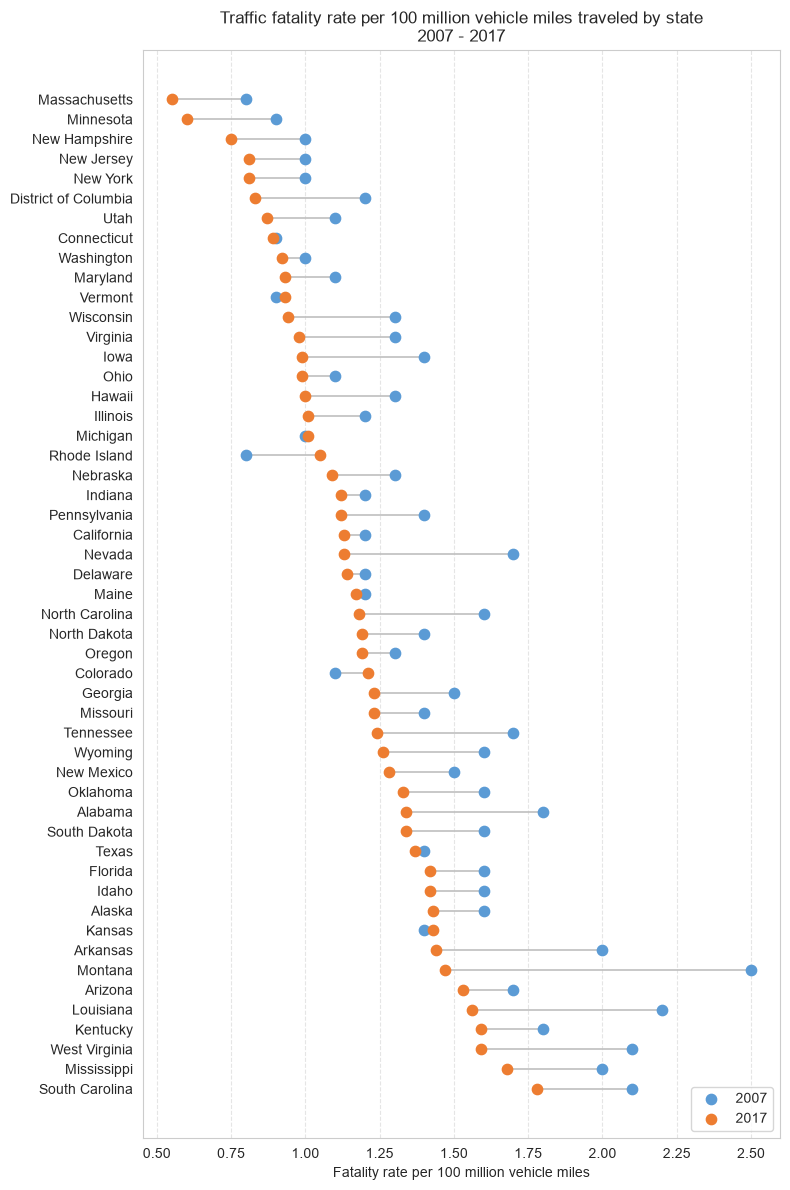

In [4]:
blue   = "#5B9BD5"   # 2007
orange = "#ED7D31"   # 2017

y = np.arange(len(dumbbell))

fig, ax = plt.subplots(figsize=(8, 12))

# connector line between the two years
ax.hlines(y=y, xmin=dumbbell["2007"], xmax=dumbbell["2017"],
          color="#bfbfbf", linewidth=1.2, zorder=1)

# the two dots
ax.scatter(dumbbell["2007"], y, color=blue,   s=55, zorder=2, label="2007")
ax.scatter(dumbbell["2017"], y, color=orange, s=55, zorder=2, label="2017")

ax.set_yticks(y)
ax.set_yticklabels(dumbbell["State"])
ax.invert_yaxis()                      # lowest 2017 rate at the top

ax.set_xlabel("Fatality rate per 100 million vehicle miles")
ax.set_title("Traffic fatality rate per 100 million vehicle miles traveled by state\n2007 - 2017")
ax.legend(loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### Version 2 - Plotly (interactive)

The same chart built with Plotly so the individual values can be inspected on hover. States are
plotted in descending order here because Plotly stacks categories from the bottom up, which puts
the lowest 2017 rate back at the top.

In [5]:
dd = dumbbell.sort_values("2017", ascending=False)

fig = go.Figure()

# connector lines
for _, r in dd.iterrows():
    fig.add_trace(go.Scatter(
        x=[r["2007"], r["2017"]], y=[r["State"], r["State"]],
        mode="lines", line=dict(color="#bfbfbf", width=1.5),
        showlegend=False, hoverinfo="skip"))

fig.add_trace(go.Scatter(x=dd["2007"], y=dd["State"], mode="markers",
                         marker=dict(color=blue, size=9), name="2007"))
fig.add_trace(go.Scatter(x=dd["2017"], y=dd["State"], mode="markers",
                         marker=dict(color=orange, size=9), name="2017"))

fig.update_layout(
    title="Traffic fatality rate per 100 million vehicle miles traveled by state (2007 - 2017)",
    xaxis_title="Fatality rate per 100 million vehicle miles",
    height=950, width=800, plot_bgcolor="white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))
fig.update_xaxes(showgrid=True, gridcolor="#eeeeee")
fig.show()

## Part II - Histograms and Heatmap

The file `covid_china_daily_70days_2.csv` holds 70 days of daily COVID cases for each Chinese
province (one column per province).

In [6]:
covid = pd.read_csv("covid_china_daily_70days_2.csv")
print(covid.shape, "-> 70 days x", covid.shape[1], "provinces")
covid.head()

(70, 34) -> 70 days x 34 provinces


,Anhui,Beijing,Chongqing,Fujian,Gansu,Guangdong,Guangxi,Guizhou,Hainan,Hebei,...,Shandong,Shanghai,Shanxi,Sichuan,Tianjin,Tibet,Unknown,Xinjiang,Yunnan,Zhejiang
0,0,18,22,23,3,299,0,0,0,1,...,1,4,16,8,3,0,2351,30,4,1
1,1,33,10,95,3,249,0,2,0,0,...,7,5,17,13,2,0,2223,23,4,0
2,0,67,23,129,0,250,0,0,0,0,...,5,12,24,21,3,0,2382,55,5,2
3,1,38,44,54,8,208,0,2,0,0,...,6,3,28,22,0,0,2699,0,6,1
4,0,41,40,62,0,228,0,1,0,0,...,10,6,91,21,4,0,3212,42,19,1


### 1. Reproduce the Chongqing histograms

The assignment asks for the daily-case distribution of **Chongqing** at bin sizes
**1, 5, 15, 50 and 100**. A bin size here is the width of each bin, so the edges run from 0 to the
maximum observed value in steps of that width.

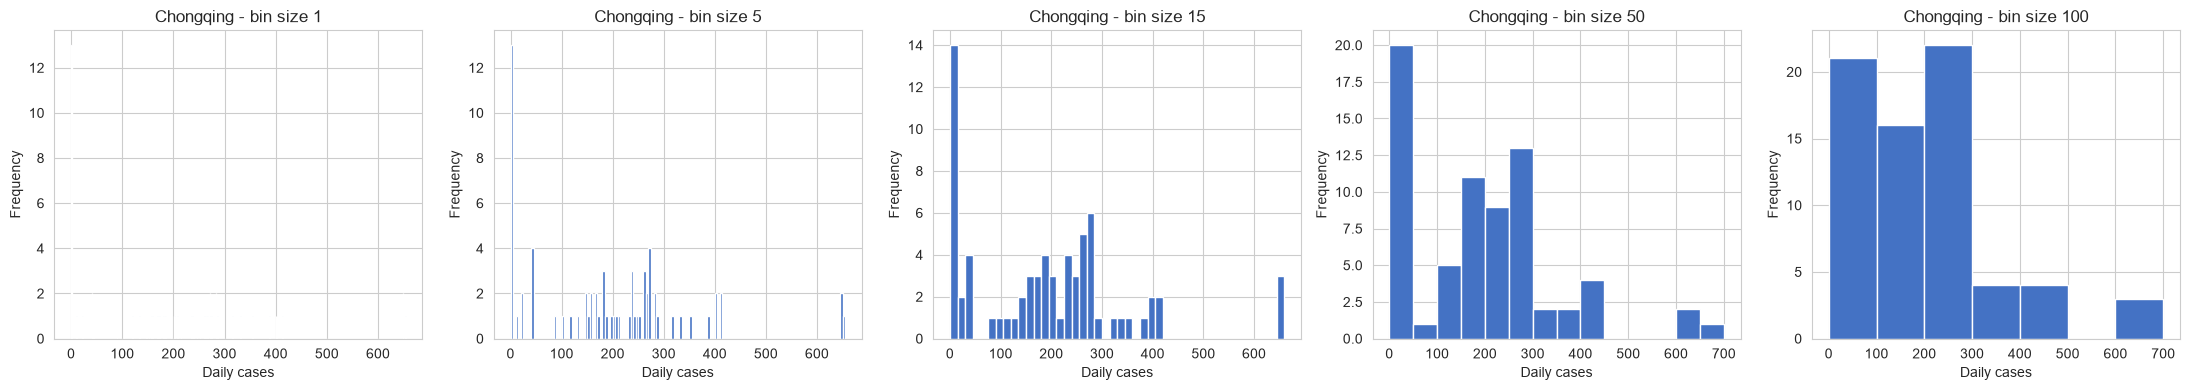

In [7]:
bin_sizes = [1, 5, 15, 50, 100]
chongqing = covid["Chongqing"]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, b in zip(axes, bin_sizes):
    edges = np.arange(0, chongqing.max() + b, b)
    ax.hist(chongqing, bins=edges, color="#4472C4", edgecolor="white")
    ax.set_title(f"Chongqing - bin size {b}")
    ax.set_xlabel("Daily cases")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

### 2-4. Bhattacharyya similarity matrix and heatmaps

The Bhattacharyya coefficient measures the overlap between two probability distributions:

$$BC(P,Q) = \sum_i \sqrt{P(i)\,Q(i)}$$

To compare two provinces I build a histogram for each using the **same bin edges**, normalise each
histogram into a probability distribution (divide every bin by the total count), then apply the
formula above. Doing this for every pair of provinces gives an N x N similarity matrix
(N = number of provinces). A value of 1 means the two distributions are identical.

In [8]:
def bhattacharyya_coefficient(p, q):
    """Overlap between two histograms after normalising them to probabilities."""
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    if p.sum() == 0 or q.sum() == 0:
        return 0.0
    p = p / p.sum()
    q = q / q.sum()
    return float(np.sum(np.sqrt(p * q)))


def similarity_matrix(data, bin_size):
    """N x N Bhattacharyya similarity matrix over all provinces for one bin size."""
    provinces = list(data.columns)
    edges = np.arange(0, data.values.max() + bin_size, bin_size)

    # one histogram per province, all sharing the same edges
    hists = {p: np.histogram(data[p], bins=edges)[0] for p in provinces}

    n = len(provinces)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            matrix[i, j] = bhattacharyya_coefficient(hists[provinces[i]], hists[provinces[j]])
    return pd.DataFrame(matrix, index=provinces, columns=provinces)

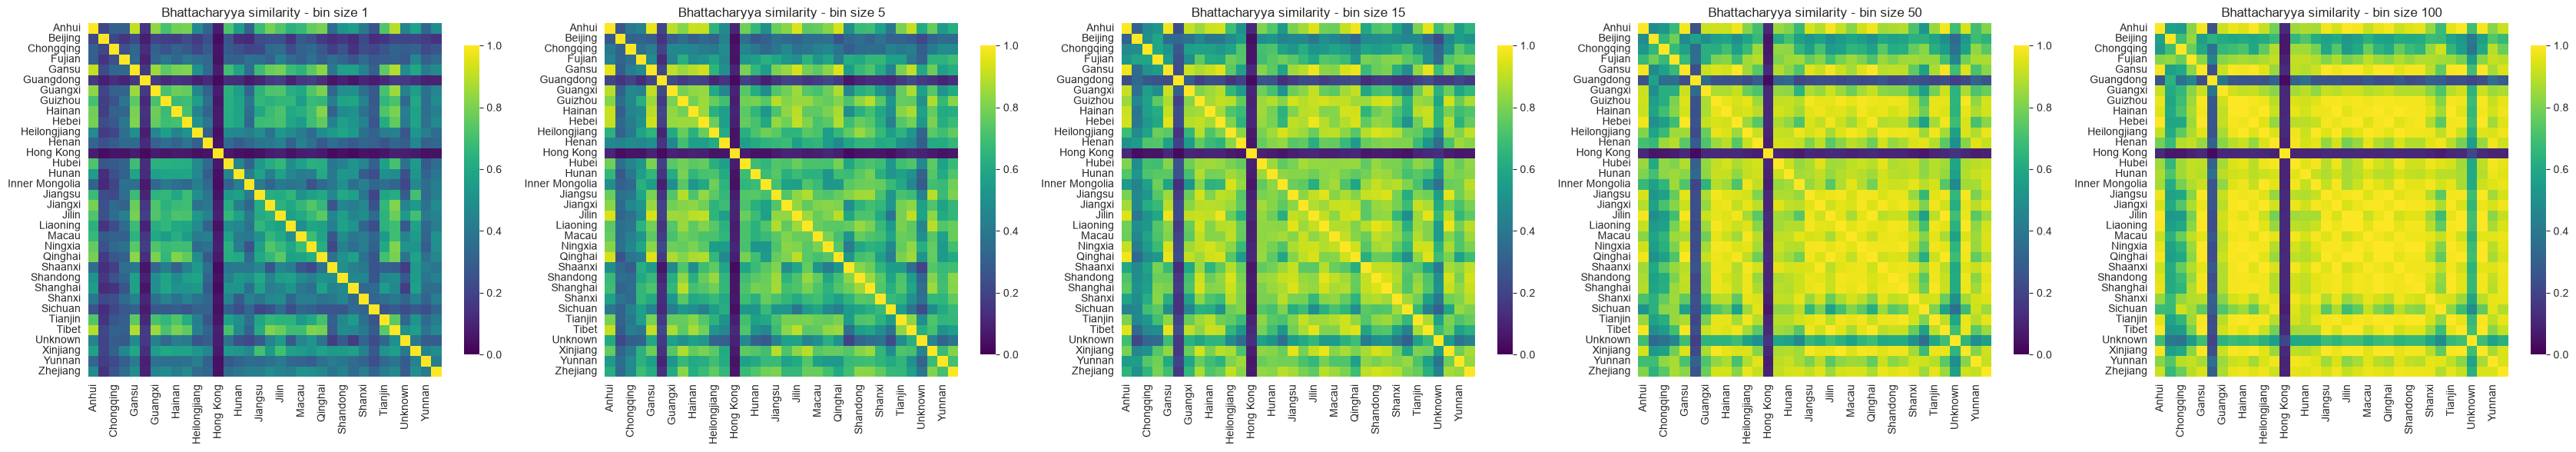

In [9]:
# build and plot a heatmap of the similarity matrix for every bin size
matrices = {}
fig, axes = plt.subplots(1, 5, figsize=(34, 7))
for ax, b in zip(axes, bin_sizes):
    sim = similarity_matrix(covid, b)
    matrices[b] = sim
    sns.heatmap(sim, ax=ax, cmap="viridis", vmin=0, vmax=1,
                square=True, cbar_kws={"shrink": 0.6})
    ax.set_title(f"Bhattacharyya similarity - bin size {b}")
plt.tight_layout()
plt.show()

### 5-6. Analysis - the effect of bin size

**What the heatmaps show.** The diagonal is always 1 (every province is identical to itself). Off
the diagonal, the similarity values rise as the bin size grows:

- **Small bins (1, 5).** With very narrow bins almost every daily value falls into its own bin, so
  two provinces only "overlap" when they happen to record the exact same counts. The matrix is
  therefore mostly dark - low similarity everywhere except the diagonal. The measure is extremely
  sensitive to small differences and exaggerates how *dissimilar* provinces are.

- **Medium bins (15, 50).** Counts start sharing bins, overlap increases and structure appears:
  provinces with similarly shaped distributions (many low-case days) light up as more similar,
  while the few high-volume provinces (e.g. Hubei) stay distinct.

- **Large bins (100).** Most daily counts collapse into the first one or two bins, so nearly every
  province looks alike and the heatmap becomes uniformly bright. Real differences are washed out -
  the measure now *over*-states similarity.

**Takeaway on bin size.** Bin size is a smoothing knob. Too small and the Bhattacharyya coefficient
is dominated by noise and reports almost everything as different; too large and it loses resolution
and reports almost everything as the same. A moderate bin size (around 15-50 for this data) gives
the most informative heatmap - enough overlap to compare distributions while still preserving the
genuine differences between provinces.